In [19]:
import pandas as pd
import numpy as np
root="C:/Users/nefel/Desktop/Virality-on-Shorts" # TO CHANGE according to your local path

# Carichiamo i dataset puliti
instagram = pd.read_csv(root + "/data/clean/instagram_clean.csv")
tiktok = pd.read_csv(root + "/data/clean/tiktok_clean.csv")
youtube = pd.read_csv(root + "/data/clean/youtube_clean.csv")

# Filtriamo i publisher attivi per ogni piattaforma
from tools import filter_active_publisher_years
youtube_active, yt_publishers, yt_counts = filter_active_publisher_years(
    df=youtube,
    platform_name="YouTube",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=50
)

instagram_active, ig_publishers, ig_counts = filter_active_publisher_years(
    df=instagram,
    platform_name="Instagram",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=50
)

tiktok_active, tt_publishers, tt_counts = filter_active_publisher_years(
    df=tiktok,
    platform_name="TikTok",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=50
)


# Selezioniamo le colonne di interesse
tiktok=tiktok_active[['video_id','publisher', 'year','views','platform']]
youtube=youtube_active[['video_id','publisher', 'year','views','platform']]
instagram=instagram_active[['video_id','publisher', 'year','views','platform']]

tiktok['views'] =np.log(tiktok['views'].astype(int) + 1)
youtube['views'] =np.log(youtube['views'].astype(int) + 1)
instagram['views'] =np.log(instagram['views'].astype(int) + 1)


YouTube
-------
Original videos:              51,858
Original publishers:          130
Videos after filtering:       48,299
Unique publishers retained:   62

Publisher-years retained by year:
year
2022     9
2023    21
2024    27
2025    49
2026    43
Name: count, dtype: int64

Instagram
---------
Original videos:              233,279
Original publishers:          161
Videos after filtering:       228,409
Unique publishers retained:   140

Publisher-years retained by year:
year
2022     38
2023    107
2024    115
2025    129
2026    114
Name: count, dtype: int64

TikTok
------
Original videos:              194,812
Original publishers:          160
Videos after filtering:       191,177
Unique publishers retained:   130

Publisher-years retained by year:
year
2022     30
2023     69
2024     85
2025    102
2026     94
Name: count, dtype: int64


C:\Users\nefel\AppData\Local\Temp\ipykernel_13440\3183682785.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tiktok['views'] =np.log(tiktok['views'].astype(int) + 1)
C:\Users\nefel\AppData\Local\Temp\ipykernel_13440\3183682785.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  youtube['views'] =np.log(youtube['views'].astype(int) + 1)
C:\Users\nefel\AppData\Local\Temp\ipykernel_13440\3183682785.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

Preview of channel-year summary table:
    platform  publisher  year  n_videos_original  ratio_mean  ratio_ci_low  \
0  Instagram      AMICA  2023                101    1.373470      1.134185   
1  Instagram      AMICA  2024                189    1.813679      1.397072   
2  Instagram      AMICA  2025                243    2.395229      1.264230   
3  Instagram      AMICA  2026                101    2.279833      1.273463   
4  Instagram  Adnkronos  2023                128    1.723852      0.972595   

   ratio_ci_high  
0       1.709526  
1       2.942265  
2       3.081245  
3       3.029246  
4       2.928108  

Total channel-years analyzed: 1032
Percentile alto usato: P95 | Percentile basso: P50

OPTION A - Quantile Ratio (P95 - P50, log scale)
            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   ratio_mean
No. Observations:   1032      Method:               REML      
No. Groups:         313       Scale:                0.3828    
Mi

C:\Users\nefel\AppData\Local\Temp\ipykernel_13440\1094465470.py:149: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\nefel\AppData\Local\Temp\ipykernel_13440\1094465470.py:150: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\nefel\AppData\Local\Temp\ipykernel_13440\1094465470.py:183: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



Saved 3 figures (PDF + PNG) to 'figures_A/'


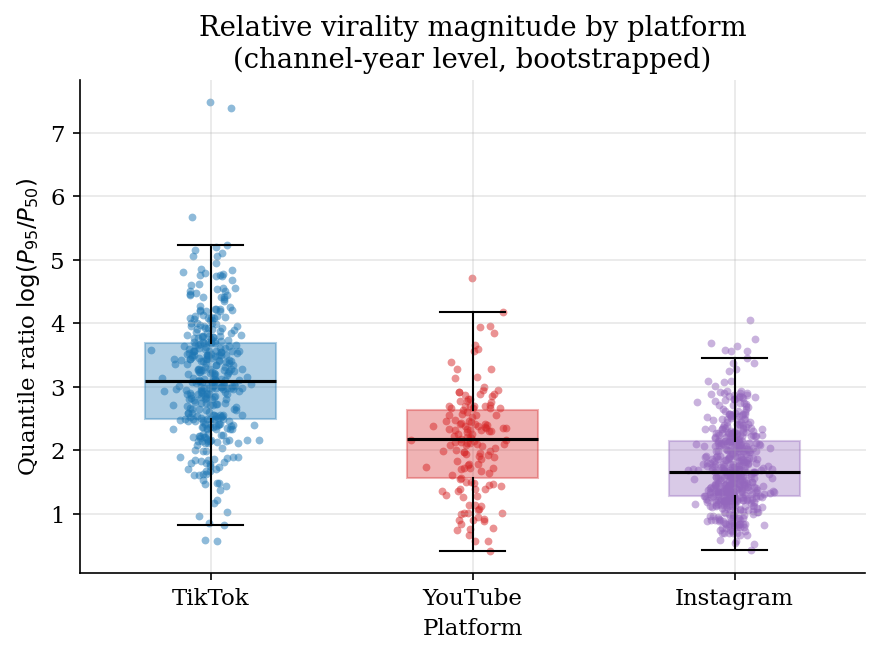

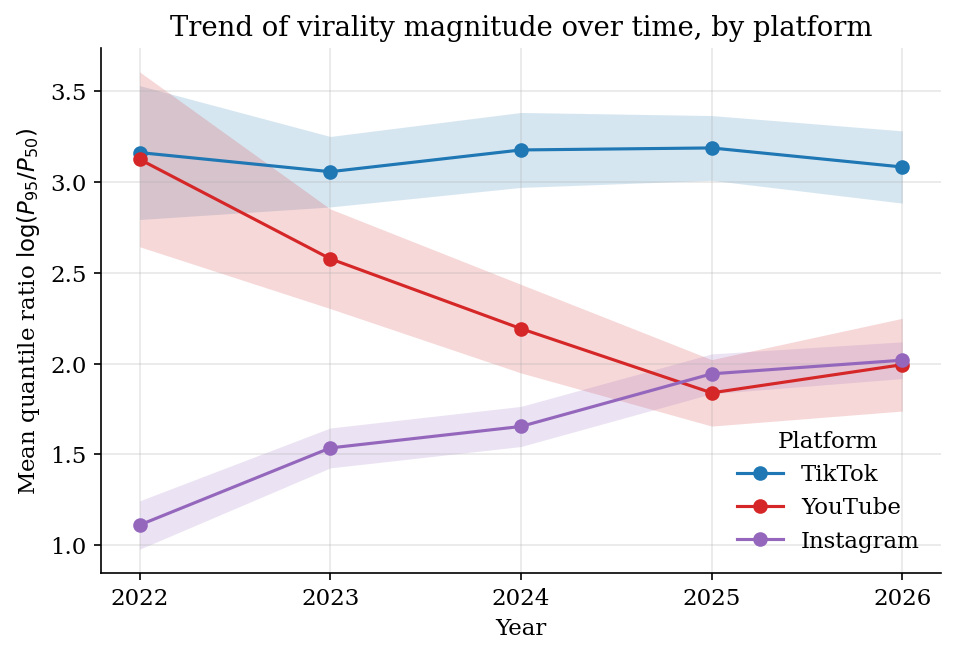

In [15]:
"""
Option A - Quantile Ratio (relative magnitude of virality)
============================================================
Metric: ratio_mean = P{Q_HIGH} - P{Q_LOW} (log scale)
Since log_views is already natural-log transformed, this difference
equals log(P_high / P_low) in the original views scale: how "explosive"
the upper tail is relative to the channel's typical video.

Bootstrap rationale
--------------------
Channels have different numbers of videos per year (>=70, but not
equal). Tail quantiles are sensitive to sample size, so we resample
with replacement to a fixed N=100 per channel-year, repeated B=100
times, and average. This makes the metric comparable "at equal
exposure" across channels/platforms.

Expected input
--------------
tiktok, youtube, instagram: DataFrames with columns
  ['video_id', 'publisher', 'year', 'views', 'platform']
where 'views' is already np.log(views + 1).

Plots (for paper)
-----------------
Fig. 1: Boxplot of ratio_mean by platform -> distribution comparison
Fig. 2: ratio_mean vs n_videos_original by platform -> confound check
Fig. 3: ratio_mean trend over year by platform (mean +/- 95% CI)
"""

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

np.random.seed(42)

N_BOOT = 100
B_REPLICATES = 100

# --- Parametro iniziale: percentile più alto usato nel quantile ratio ---
Q_HIGH = 0.95      # percentile alto (es. 0.95 = P95)
Q_LOW = 0.5       # percentile basso di riferimento (mediana)

FIGURE_DIR = "figures_A"

# ----------------------------------------------------------------------
# Publication-style matplotlib settings
# ----------------------------------------------------------------------
PLATFORM_COLORS = {
    "TikTok": "#1f77b4",
    "YouTube": "#d62728",
    "Instagram": "#9467bd",
}

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.frameon": False,
})


def quantile_ratio(x, q_high=Q_HIGH, q_low=Q_LOW):
    """P_high - P_low in log scale = log(P_high / P_low) in original scale."""
    return np.quantile(x, q_high) - np.quantile(x, q_low)


def bootstrap_quantile_ratio(all_data, q_high=Q_HIGH, q_low=Q_LOW):
    records = []
    for key, grp in all_data.groupby("group_key"):
        views = grp["log_views"].values
        platform = grp["platform"].iloc[0]
        publisher = grp["publisher"].iloc[0]
        year = grp["year"].iloc[0]
        n_original = len(views)

        ratio_boot = []
        for _ in range(B_REPLICATES):
            sample = np.random.choice(views, size=N_BOOT, replace=True)
            ratio_boot.append(quantile_ratio(sample, q_high=q_high, q_low=q_low))

        records.append({
            "platform": platform,
            "publisher": publisher,
            "year": year,
            "n_videos_original": n_original,
            "ratio_mean": np.mean(ratio_boot),
            "ratio_ci_low": np.percentile(ratio_boot, 2.5),
            "ratio_ci_high": np.percentile(ratio_boot, 97.5),
        })
    return pd.DataFrame(records)


def _platform_order(summary):
    """Consistent platform ordering/colors across all figures."""
    preferred = [p for p in ["TikTok", "YouTube", "Instagram"] if p in summary["platform"].unique()]
    return preferred or sorted(summary["platform"].unique())


def _color_for(platform):
    return PLATFORM_COLORS.get(platform, "#7f7f7f")


def _quantile_label(q_high=Q_HIGH, q_low=Q_LOW):
    """Etichetta LaTeX per l'asse, es. 'P_{95}/P_{50}' se q_high=0.95."""
    return r"$\log(P_{%d}/P_{%d})$" % (round(q_high * 100), round(q_low * 100))


def plot_boxplot_by_platform(summary, out_dir, q_high=Q_HIGH, q_low=Q_LOW):
    """Fig. 1: distribution of ratio_mean by platform (boxplot + jittered points)."""
    platforms = _platform_order(summary)
    fig, ax = plt.subplots(figsize=(6, 4.5))

    data = [summary.loc[summary["platform"] == p, "ratio_mean"].values for p in platforms]
    bp = ax.boxplot(
        data,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.5},
    )
    # Set tick labels manually (avoids the 'labels'/'tick_labels' kwarg
    # rename across matplotlib versions: removed in 3.9+, renamed in 3.11+)
    ax.set_xticks(range(1, len(platforms) + 1))
    ax.set_xticklabels(platforms)
    for patch, p in zip(bp["boxes"], platforms):
        patch.set_facecolor(_color_for(p))
        patch.set_alpha(0.35)
        patch.set_edgecolor(_color_for(p))

    rng = np.random.default_rng(0)
    for i, (p, vals) in enumerate(zip(platforms, data), start=1):
        jitter = rng.normal(0, 0.06, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=_color_for(p), alpha=0.5, s=14, linewidths=0)

    ax.set_ylabel(f"Quantile ratio {_quantile_label(q_high, q_low)}")
    ax.set_xlabel("Platform")
    ax.set_title("Relative virality magnitude by platform\n(channel-year level, bootstrapped)")

    fig.tight_layout()
    fig.show()
    fig.show()




def plot_ratio_trend_by_year(summary, out_dir, q_high=Q_HIGH, q_low=Q_LOW):
    """Fig. 3: yearly mean ratio_mean +/- 95% CI, by platform."""
    platforms = _platform_order(summary)
    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    for p in platforms:
        sub = summary[summary["platform"] == p].copy()
        sub["year"] = sub["year"].astype(int)
        grouped = sub.groupby("year")["ratio_mean"].agg(["mean", "std", "count"]).reset_index()
        grouped["se"] = grouped["std"] / np.sqrt(grouped["count"])
        grouped["ci95"] = 1.96 * grouped["se"]
        grouped = grouped.sort_values("year")

        ax.plot(grouped["year"], grouped["mean"], marker="o", color=_color_for(p), label=p)
        ax.fill_between(
            grouped["year"],
            grouped["mean"] - grouped["ci95"],
            grouped["mean"] + grouped["ci95"],
            color=_color_for(p), alpha=0.18, linewidth=0,
        )

    ax.set_xlabel("Year")
    ax.set_ylabel(f"Mean quantile ratio {_quantile_label(q_high, q_low)}")
    ax.set_title("Trend of virality magnitude over time, by platform")
    ax.set_xticks(sorted(summary["year"].astype(int).unique()))
    ax.legend(title="Platform", loc="best")

    fig.tight_layout()
    fig.show()


def generate_plots(summary, out_dir=FIGURE_DIR, q_high=Q_HIGH, q_low=Q_LOW):
    os.makedirs(out_dir, exist_ok=True)
    plot_boxplot_by_platform(summary, out_dir, q_high=q_high, q_low=q_low)
    plot_ratio_trend_by_year(summary, out_dir, q_high=q_high, q_low=q_low)
    print(f"\nSaved 3 figures (PDF + PNG) to '{out_dir}/'")


def main(q_high=Q_HIGH, q_low=Q_LOW):

    all_data = pd.concat([tiktok, youtube, instagram], ignore_index=True)
    all_data = all_data.rename(columns={"views": "log_views"})
    all_data["group_key"] = (
        all_data["platform"].astype(str) + "_" +
        all_data["publisher"].astype(str) + "_" +
        all_data["year"].astype(str)
    )

    # --- 2. Bootstrap the quantile-ratio metric per channel-year ---
    summary = bootstrap_quantile_ratio(all_data, q_high=q_high, q_low=q_low)
    summary["year"] = summary["year"].astype(str)

    print("Preview of channel-year summary table:")
    print(summary.head())
    print(f"\nTotal channel-years analyzed: {len(summary)}")
    print(f"Percentile alto usato: P{round(q_high*100)} | Percentile basso: P{round(q_low*100)}")

    # --- 3. Mixed model: ratio ~ platform + year + activity, random effect per channel ---
    model_E = smf.mixedlm(
        "ratio_mean ~ platform + year + n_videos_original",
        data=summary,
        groups=summary["publisher"],
    ).fit()

    print("\n" + "=" * 70)
    print(f"OPTION A - Quantile Ratio (P{round(q_high*100)} - P{round(q_low*100)}, log scale)")
    print("=" * 70)
    print(model_E.summary())


    print("\nSaved: virality_option_a_summary.csv")

    # --- 4. Plots for the paper ---
    generate_plots(summary, q_high=q_high, q_low=q_low)


if __name__ == "__main__":
    main(q_high=Q_HIGH, q_low=Q_LOW)

# Clean Data - QUANTILE RATIO BY PUBLISHER-QUARTER

In [20]:
import pandas as pd
import numpy as np

root = "C:/Users/nefel/Desktop/Virality-on-Shorts"

# Load cleaned datasets
instagram = pd.read_csv(root + "/data/clean/instagram_clean.csv")
tiktok = pd.read_csv(root + "/data/clean/tiktok_clean.csv")
youtube = pd.read_csv(root + "/data/clean/youtube_clean.csv")

# Filter active publisher-years
from tools import filter_active_publisher_years

youtube_active, yt_publishers, yt_counts = filter_active_publisher_years(
    df=youtube,
    platform_name="YouTube",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=50
)

instagram_active, ig_publishers, ig_counts = filter_active_publisher_years(
    df=instagram,
    platform_name="Instagram",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=50
)

tiktok_active, tt_publishers, tt_counts = filter_active_publisher_years(
    df=tiktok,
    platform_name="TikTok",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=50
)

# Keep published_at because we need it for quarters
cols = ["video_id", "publisher", "published_at", "year", "views", "platform"]

tiktok = tiktok_active[cols].copy()
youtube = youtube_active[cols].copy()
instagram = instagram_active[cols].copy()

# Convert dates and views
for df in [tiktok, youtube, instagram]:

    df["published_at"] = pd.to_datetime(
        df["published_at"],
        utc=True,
        errors="coerce"
    )

    df["views"] = pd.to_numeric(
        df["views"],
        errors="coerce"
    )

    df.dropna(
        subset=["published_at", "publisher", "platform", "views"],
        inplace=True
    )

    df["views"] = np.log(df["views"].astype(int) + 1)


YouTube
-------
Original videos:              51,858
Original publishers:          130
Videos after filtering:       48,299
Unique publishers retained:   62

Publisher-years retained by year:
year
2022     9
2023    21
2024    27
2025    49
2026    43
Name: count, dtype: int64

Instagram
---------
Original videos:              233,279
Original publishers:          161
Videos after filtering:       228,409
Unique publishers retained:   140

Publisher-years retained by year:
year
2022     38
2023    107
2024    115
2025    129
2026    114
Name: count, dtype: int64

TikTok
------
Original videos:              194,812
Original publishers:          160
Videos after filtering:       191,177
Unique publishers retained:   130

Publisher-years retained by year:
year
2022     30
2023     69
2024     85
2025    102
2026     94
Name: count, dtype: int64


In [21]:
# =============================================================================
# BUILD QUARTERLY DATASET
# views is already log-transformed
# =============================================================================

all_data_quarterly_base = pd.concat(
    [tiktok, youtube, instagram],
    ignore_index=True
)

all_data_quarterly_base["year"] = (
    all_data_quarterly_base["published_at"]
    .dt.year
)

all_data_quarterly_base["quarter"] = (
    all_data_quarterly_base["published_at"]
    .dt.quarter
)

all_data_quarterly_base["year_quarter"] = (
    all_data_quarterly_base["published_at"]
    .dt.tz_convert(None)
    .dt.to_period("Q")
)

all_data_quarterly_base["group_key"] = (
    all_data_quarterly_base["platform"].astype(str) + "_" +
    all_data_quarterly_base["publisher"].astype(str) + "_" +
    all_data_quarterly_base["year_quarter"].astype(str)
)

In [ ]:
# Threshold Test
thresholds = [10, 15, 20, 30, 40]

threshold_report = []

group_sizes = (
    all_data_quarterly_base
    .groupby("group_key")
    .size()
    .rename("n_videos_quarter")
    .reset_index()
)

for threshold in thresholds:

    valid_groups = group_sizes[
        group_sizes["n_videos_quarter"] >= threshold
    ]

    temp = all_data_quarterly_base[
        all_data_quarterly_base["group_key"].isin(valid_groups["group_key"])
    ].copy()

    threshold_report.append({
        "min_videos_per_quarter": threshold,
        "publisher_quarters_retained": valid_groups["group_key"].nunique(),
        "videos_retained": len(temp),
        "publishers_retained": temp["publisher"].nunique()
    })

threshold_report = pd.DataFrame(threshold_report)

display(threshold_report)

,min_videos_per_quarter,publisher_quarters_retained,videos_retained,publishers_retained
0,10,3229,466969,313
1,15,3081,465148,313
2,20,2898,462022,311
3,30,2561,453759,292
4,40,2265,443604,269


In [24]:
# =============================================================================
# 6. APPLY FINAL PUBLISHER-QUARTER THRESHOLD
# =============================================================================

MIN_VIDEOS_PER_QUARTER = 30

valid_groups = group_sizes[
    group_sizes["n_videos_quarter"] >= MIN_VIDEOS_PER_QUARTER
]["group_key"]

all_data = all_data_quarterly_base[
    all_data_quarterly_base["group_key"].isin(valid_groups)
].copy()

print(f"Minimum videos per publisher-quarter: {MIN_VIDEOS_PER_QUARTER}")
print(f"Publisher-quarters retained: {all_data['group_key'].nunique()}")
print(f"Videos retained: {len(all_data)}")
print(f"Publishers retained: {all_data['publisher'].nunique()}")


Minimum videos per publisher-quarter: 30
Publisher-quarters retained: 2561
Videos retained: 453759
Publishers retained: 292


Preview of publisher-quarter summary table:


,platform,publisher,year,quarter,year_quarter,n_videos_original,ratio_mean,ratio_ci_low,ratio_ci_high
0,Instagram,AMICA,2023,3,2023Q3,31,1.748342,1.339588,2.616821
1,Instagram,AMICA,2023,4,2023Q4,30,1.599517,1.239626,2.555538
2,Instagram,AMICA,2024,1,2024Q1,50,1.964904,1.574619,2.580189
3,Instagram,AMICA,2024,2,2024Q2,39,1.618865,1.273066,1.858694
4,Instagram,AMICA,2024,3,2024Q3,50,2.590424,1.518014,3.205116



Total publisher-quarters analyzed: 2561
High percentile: P95
Low percentile: P50
Minimum videos per publisher-quarter: 30

OPTION A - Quarterly Quantile Ratio (P95 - P50, log scale)
            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   ratio_mean
No. Observations:   2561      Method:               REML      
No. Groups:         292       Scale:                0.4125    
Min. group size:    1         Log-Likelihood:       -2790.3724
Max. group size:    32        Converged:            Yes       
Mean group size:    8.8                                       
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            1.631    0.083 19.705 0.000  1.469  1.793
platform[T.TikTok]   1.294    0.074 17.531 0.000  1.149  1.439
platform[T.YouTube]  0.344    0.066  5.237 0.000  0.216  0.473
year[T.2023

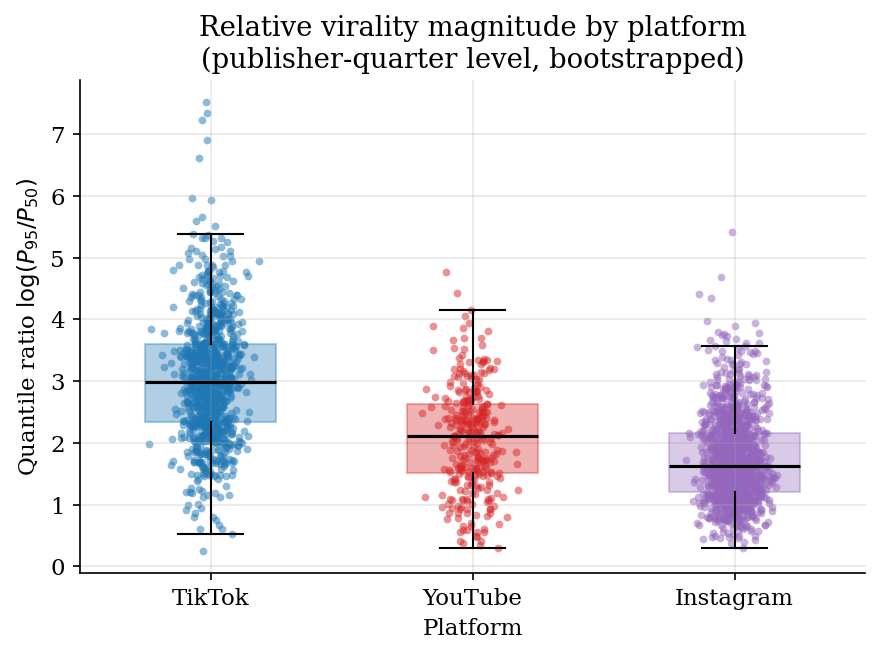

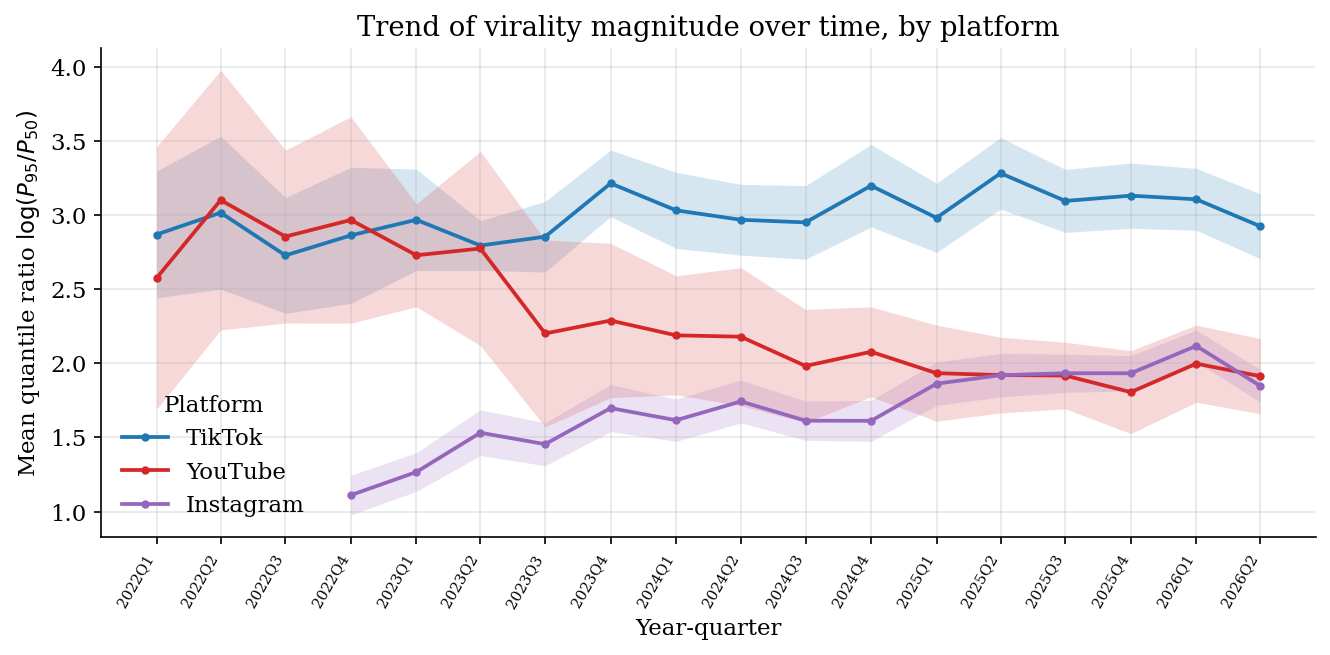

In [25]:
# =============================================================================
# 7. QUANTILE RATIO FUNCTIONS
# =============================================================================

SAMPLE_SIZE = 100
B_REPLICATES = 100

Q_HIGH = 0.95
Q_LOW = 0.50

PLATFORM_COLORS = {
    "TikTok": "#1f77b4",
    "YouTube": "#d62728",
    "Instagram": "#9467bd",
}


def quantile_ratio(x, q_high=Q_HIGH, q_low=Q_LOW):
    """
    P95 - P50 on log-transformed views.

    Since views = log(raw_views + 1), this approximates:
    log(P95 / P50)
    on the original views scale.
    """
    return np.quantile(x, q_high) - np.quantile(x, q_low)


def bootstrap_quantile_ratio_quarterly(all_data, q_high=Q_HIGH, q_low=Q_LOW):

    records = []

    for key, grp in all_data.groupby("group_key"):

        views = grp["views"].values

        platform = grp["platform"].iloc[0]
        publisher = grp["publisher"].iloc[0]
        year = grp["year"].iloc[0]
        quarter = grp["quarter"].iloc[0]
        year_quarter = grp["year_quarter"].iloc[0]
        n_original = len(views)

        ratio_boot = []

        for _ in range(B_REPLICATES):

            sample = np.random.choice(
                views,
                size=SAMPLE_SIZE,
                replace=True
            )

            ratio_boot.append(
                quantile_ratio(
                    sample,
                    q_high=q_high,
                    q_low=q_low
                )
            )

        records.append({
            "platform": platform,
            "publisher": publisher,
            "year": year,
            "quarter": quarter,
            "year_quarter": year_quarter,
            "n_videos_original": n_original,
            "ratio_mean": np.mean(ratio_boot),
            "ratio_ci_low": np.percentile(ratio_boot, 2.5),
            "ratio_ci_high": np.percentile(ratio_boot, 97.5),
        })

    return pd.DataFrame(records)


def _platform_order(summary):
    return [
        p for p in ["TikTok", "YouTube", "Instagram"]
        if p in summary["platform"].unique()
    ]


def _color_for(platform):
    return PLATFORM_COLORS.get(platform, "#7f7f7f")


def _quantile_label(q_high=Q_HIGH, q_low=Q_LOW):
    return r"$\log(P_{%d}/P_{%d})$" % (
        round(q_high * 100),
        round(q_low * 100)
    )


# =============================================================================
# 8. PLOTTING FUNCTIONS
# =============================================================================

def plot_boxplot_by_platform(summary, q_high=Q_HIGH, q_low=Q_LOW):

    platforms = _platform_order(summary)

    fig, ax = plt.subplots(figsize=(6, 4.5))

    data = [
        summary.loc[
            summary["platform"] == p,
            "ratio_mean"
        ].values
        for p in platforms
    ]

    bp = ax.boxplot(
        data,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops={
            "color": "black",
            "linewidth": 1.5
        },
    )

    ax.set_xticks(range(1, len(platforms) + 1))
    ax.set_xticklabels(platforms)

    for patch, p in zip(bp["boxes"], platforms):
        patch.set_facecolor(_color_for(p))
        patch.set_alpha(0.35)
        patch.set_edgecolor(_color_for(p))

    rng = np.random.default_rng(0)

    for i, (p, vals) in enumerate(zip(platforms, data), start=1):

        jitter = rng.normal(
            0,
            0.06,
            size=len(vals)
        )

        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            color=_color_for(p),
            alpha=0.5,
            s=14,
            linewidths=0
        )

    ax.set_ylabel(
        f"Quantile ratio {_quantile_label(q_high, q_low)}"
    )

    ax.set_xlabel("Platform")

    ax.set_title(
        "Relative virality magnitude by platform\n"
        "(publisher-quarter level, bootstrapped)"
    )

    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_ratio_trend_by_quarter(summary, q_high=Q_HIGH, q_low=Q_LOW):

    platforms = _platform_order(summary)

    summary = summary.copy()

    summary["year_quarter_date"] = pd.PeriodIndex(
        summary["year_quarter"],
        freq="Q"
    ).to_timestamp()

    summary["year_quarter_label"] = (
        summary["year_quarter"]
        .astype(str)
    )

    fig, ax = plt.subplots(figsize=(9, 4.5))

    for p in platforms:

        sub = summary[
            summary["platform"] == p
        ].copy()

        grouped = (
            sub.groupby(
                ["year_quarter", "year_quarter_date", "year_quarter_label"]
            )["ratio_mean"]
            .agg(["mean", "std", "count"])
            .reset_index()
            .sort_values("year_quarter_date")
        )

        grouped["se"] = grouped["std"] / np.sqrt(grouped["count"])
        grouped["ci95"] = 1.96 * grouped["se"]

        x = grouped["year_quarter_date"].to_numpy()
        mean = grouped["mean"].to_numpy()
        ci95 = grouped["ci95"].fillna(0).to_numpy()

        ax.plot(
            x,
            mean,
            marker="o",
            markersize=3,
            linewidth=1.8,
            color=_color_for(p),
            label=p
        )

        ax.fill_between(
            x,
            mean - ci95,
            mean + ci95,
            color=_color_for(p),
            alpha=0.18,
            linewidth=0
        )

    all_quarters = (
        summary[["year_quarter", "year_quarter_date", "year_quarter_label"]]
        .drop_duplicates()
        .sort_values("year_quarter_date")
    )

    ax.set_xticks(all_quarters["year_quarter_date"])
    ax.set_xticklabels(
        all_quarters["year_quarter_label"],
        rotation=60,
        ha="right",
        fontsize=7
    )

    ax.set_xlabel("Year-quarter")

    ax.set_ylabel(
        f"Mean quantile ratio {_quantile_label(q_high, q_low)}"
    )

    ax.set_title(
        "Trend of virality magnitude over time, by platform"
    )

    ax.legend(title="Platform", loc="best")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


# =============================================================================
# 9. RUN QUARTERLY ANALYSIS
# =============================================================================

summary_quarterly = bootstrap_quantile_ratio_quarterly(
    all_data,
    q_high=Q_HIGH,
    q_low=Q_LOW
)

print("Preview of publisher-quarter summary table:")
display(summary_quarterly.head())

print(f"\nTotal publisher-quarters analyzed: {len(summary_quarterly)}")
print(f"High percentile: P{round(Q_HIGH * 100)}")
print(f"Low percentile: P{round(Q_LOW * 100)}")
print(f"Minimum videos per publisher-quarter: {MIN_VIDEOS_PER_QUARTER}")


# =============================================================================
# 10. MIXED MODEL
# =============================================================================

summary_quarterly_model = summary_quarterly.copy()

summary_quarterly_model["year"] = (
    summary_quarterly_model["year"]
    .astype(str)
)

summary_quarterly_model["quarter"] = (
    summary_quarterly_model["quarter"]
    .astype(str)
)

model_q = smf.mixedlm(
    "ratio_mean ~ platform + year + quarter + n_videos_original",
    data=summary_quarterly_model,
    groups=summary_quarterly_model["publisher"],
).fit()

print("\n" + "=" * 70)
print(
    f"OPTION A - Quarterly Quantile Ratio "
    f"(P{round(Q_HIGH * 100)} - P{round(Q_LOW * 100)}, log scale)"
)
print("=" * 70)

print(model_q.summary())


# =============================================================================
# 11. PLOTS
# =============================================================================

plot_boxplot_by_platform(
    summary_quarterly,
    q_high=Q_HIGH,
    q_low=Q_LOW
)

plot_ratio_trend_by_quarter(
    summary_quarterly,
    q_high=Q_HIGH,
    q_low=Q_LOW
)